# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [3]:
print("bank-additional-full.csv with all examples (41188) and 20 inputs, ordered by date (from May 2008 to November 2010), very close to the data analyzed in [Moro et al., 2014]")

bank-additional-full.csv with all examples (41188) and 20 inputs, ordered by date (from May 2008 to November 2010), very close to the data analyzed in [Moro et al., 2014]


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [4]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/ygbgames/compare-classifiers/refs/heads/main/data/bank-additional-full.csv', sep = ';')

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [9]:
for column in df.columns:
    print(f"Column: {column}")
    print(df[column].unique())
    print("\n" + "-" * 30 + "\n")

Column: age
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]

------------------------------

Column: job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

------------------------------

Column: marital
['married' 'single' 'divorced' 'unknown']

------------------------------

Column: education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

------------------------------

Column: default
['no' 'unknown' 'yes']

------------------------------

Column: housing
['no' 'yes' 'unknown']

------------------------------

Column: loan
['no' 'yes' 'unknown']

------------------------------

Column: contact
['telephone' 'cellular']

---------

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [10]:
import numpy as np
import pandas as pd # Ensure pandas is imported

# Reload the DataFrame to ensure a clean state
df = pd.read_csv('https://raw.githubusercontent.com/ygbgames/compare-classifiers/refs/heads/main/data/bank-additional-full.csv', sep = ';')

# Replace 'unknown' values with NaN in specified categorical columns
for column in ['job', 'marital', 'education', 'default', 'housing', 'loan']:
    df.loc[:, column] = df[column].replace('unknown', np.nan)

# Convert 'y' column to binary (1 for 'yes', 0 for 'no') using map for robustness
df.loc[:, 'y'] = df['y'].map({'yes': 1, 'no': 0})

# Ensure 'y' is of integer type after mapping. We expect no NaNs if data is as described.
df.loc[:, 'y'] = df['y'].astype(int)

print("Missing values after 'unknown' replacement and 'y' conversion:")
print(df.isnull().sum())

print("\nUnique values in 'y' after conversion:")
print(df['y'].unique())


Missing values after 'unknown' replacement and 'y' conversion:
age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

Unique values in 'y' after conversion:
[0 1]


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             40858 non-null  object 
 2   marital         41108 non-null  object 
 3   education       39457 non-null  object 
 4   default         32591 non-null  object 
 5   housing         40198 non-null  object 
 6   loan            40198 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [12]:
print("The objective is to predict whether a client will subscribe to a term deposit (variable y) based on the other features in the dataset.")

The objective is to predict whether a client will subscribe to a term deposit (variable y) based on the other features in the dataset.


In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude the target variable 'y' from numerical features to be analyzed against itself
if 'y' in numerical_cols:
    numerical_cols.remove('y')

print("Numerical columns identified:", numerical_cols)

Numerical columns identified: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


**Reasoning:**
Now that numerical columns are identified, We will iterate through each to compare their distributions based on the target variable 'y'. we will use `groupby('y').describe()` for descriptive statistics and create histograms for a visual comparison of distributions.


--- Analysis for Numerical Feature: Age ---
     count       mean        std   min   25%   50%   75%   max
y                                                             
0  36548.0  39.911185   9.898132  17.0  32.0  38.0  47.0  95.0
1   4640.0  40.913147  13.837476  17.0  31.0  37.0  50.0  98.0


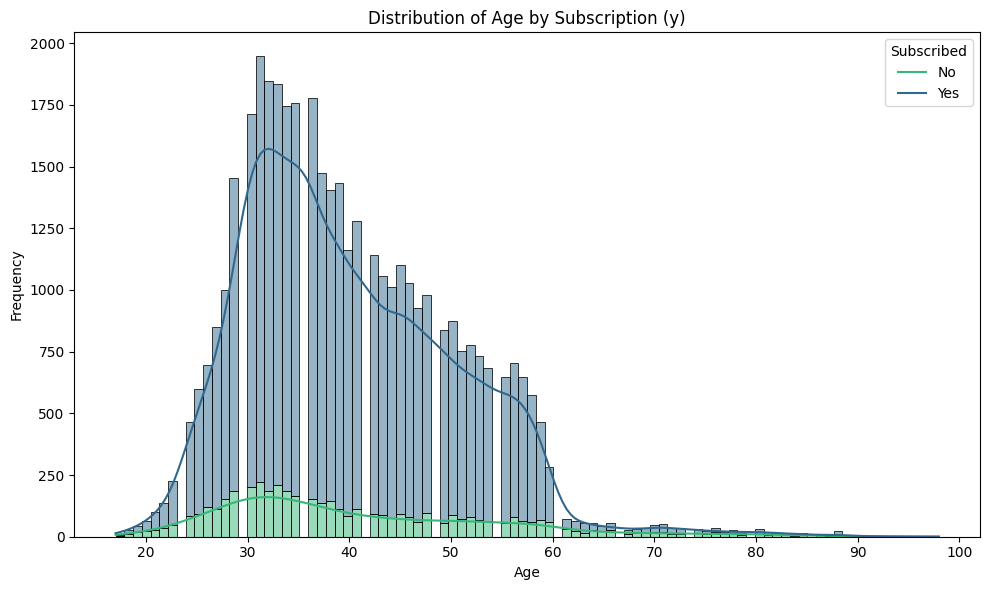

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


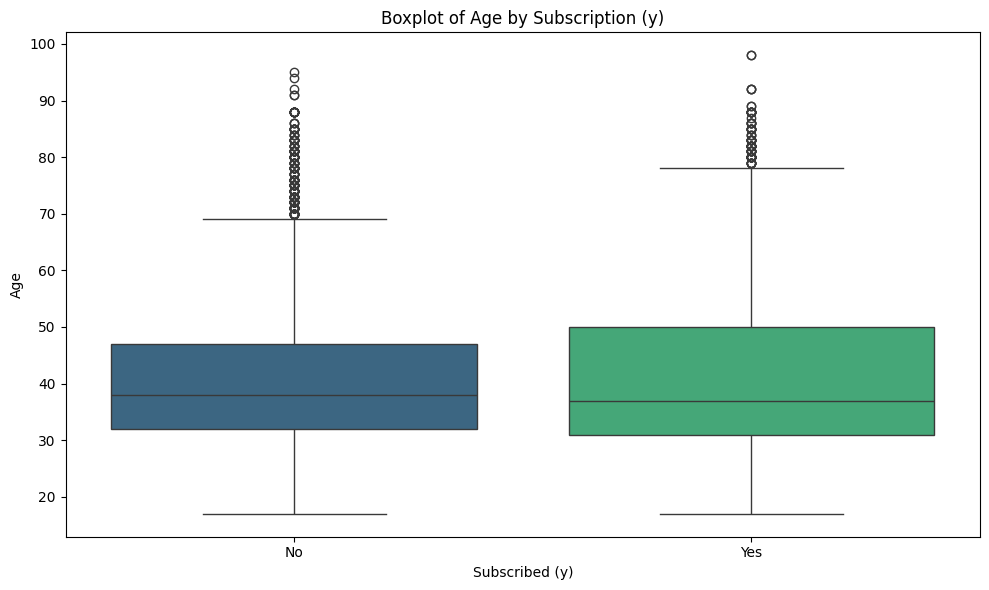


--- Analysis for Numerical Feature: Duration ---
     count        mean         std   min    25%    50%     75%     max
y                                                                     
0  36548.0  220.844807  207.096293   0.0   95.0  163.5  279.00  4918.0
1   4640.0  553.191164  401.171871  37.0  253.0  449.0  741.25  4199.0


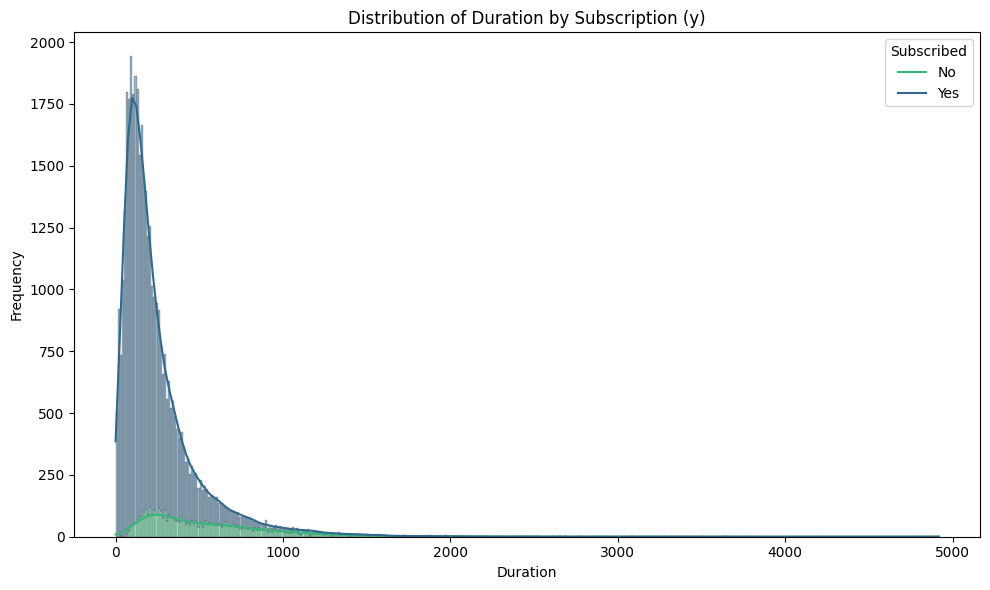

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


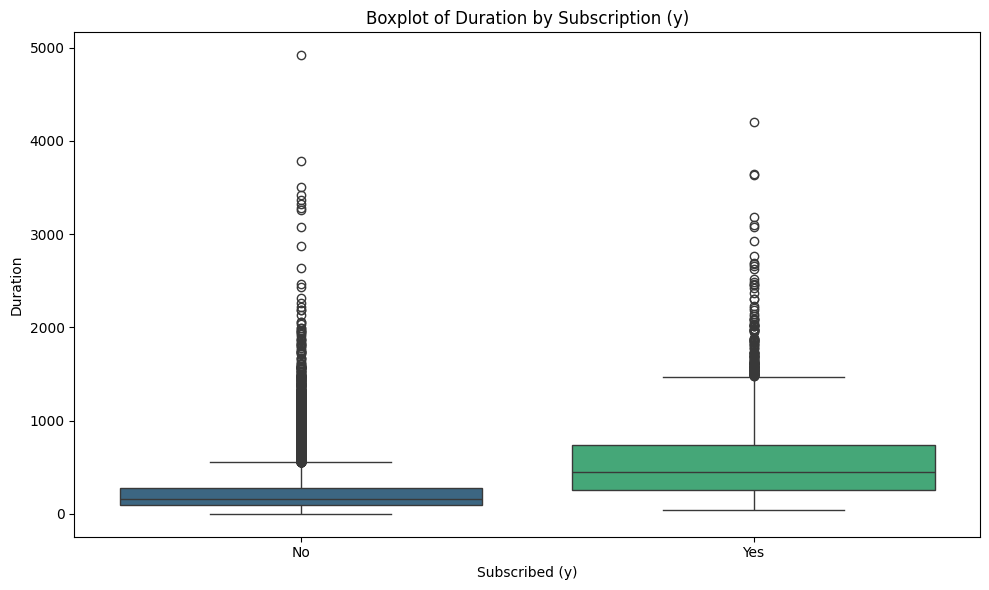


--- Analysis for Numerical Feature: Campaign ---
     count      mean       std  min  25%  50%  75%   max
y                                                       
0  36548.0  2.633085  2.873438  1.0  1.0  2.0  3.0  56.0
1   4640.0  2.051724  1.666245  1.0  1.0  2.0  2.0  23.0


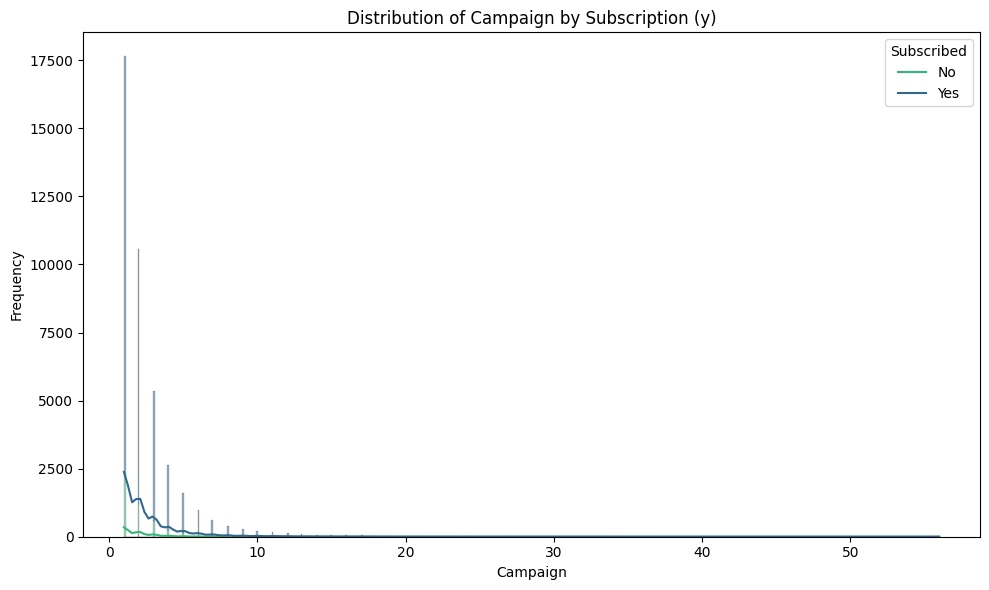

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


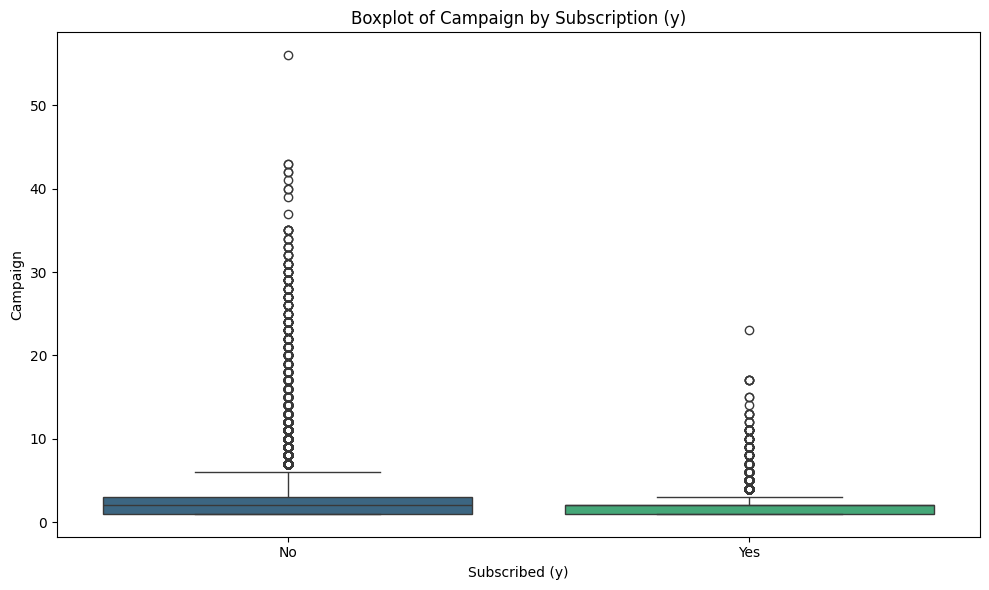


--- Analysis for Numerical Feature: Pdays ---
     count        mean         std  min    25%    50%    75%    max
y                                                                  
0  36548.0  984.113878  120.656868  0.0  999.0  999.0  999.0  999.0
1   4640.0  792.035560  403.407181  0.0  999.0  999.0  999.0  999.0


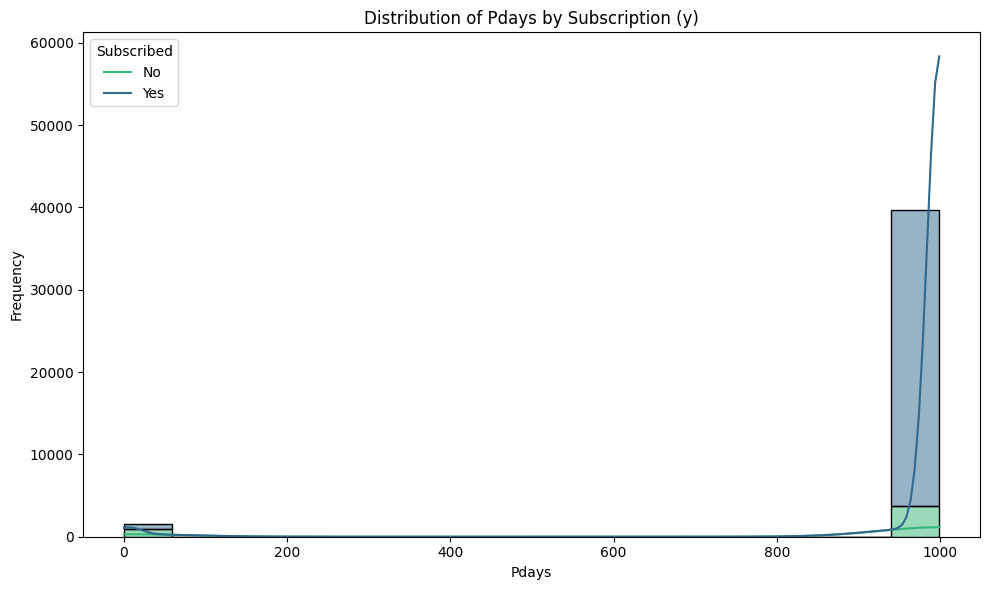

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


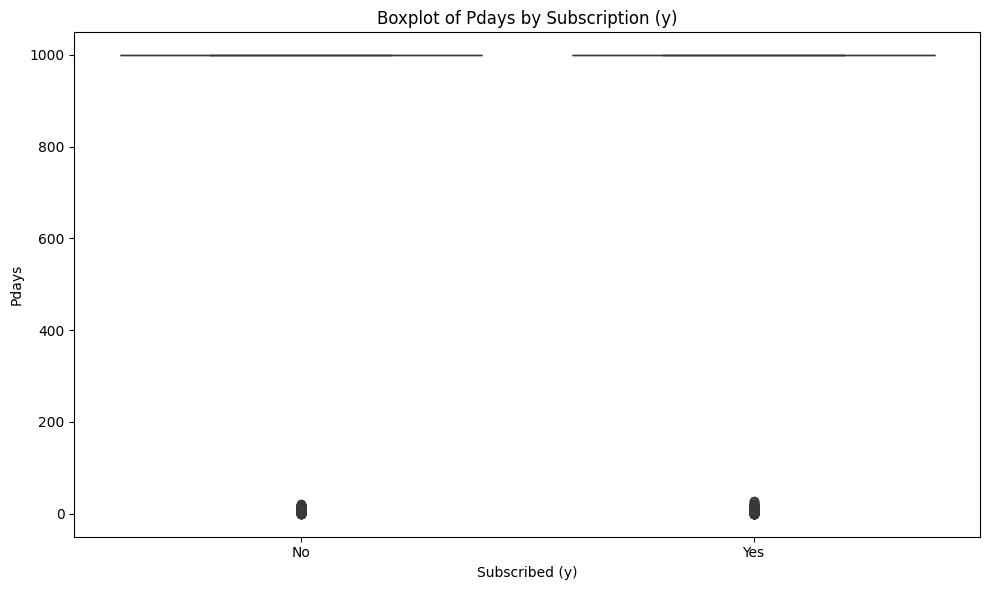


--- Analysis for Numerical Feature: Previous ---
     count      mean       std  min  25%  50%  75%  max
y                                                      
0  36548.0  0.132374  0.409199  0.0  0.0  0.0  0.0  7.0
1   4640.0  0.492672  0.860344  0.0  0.0  0.0  1.0  6.0


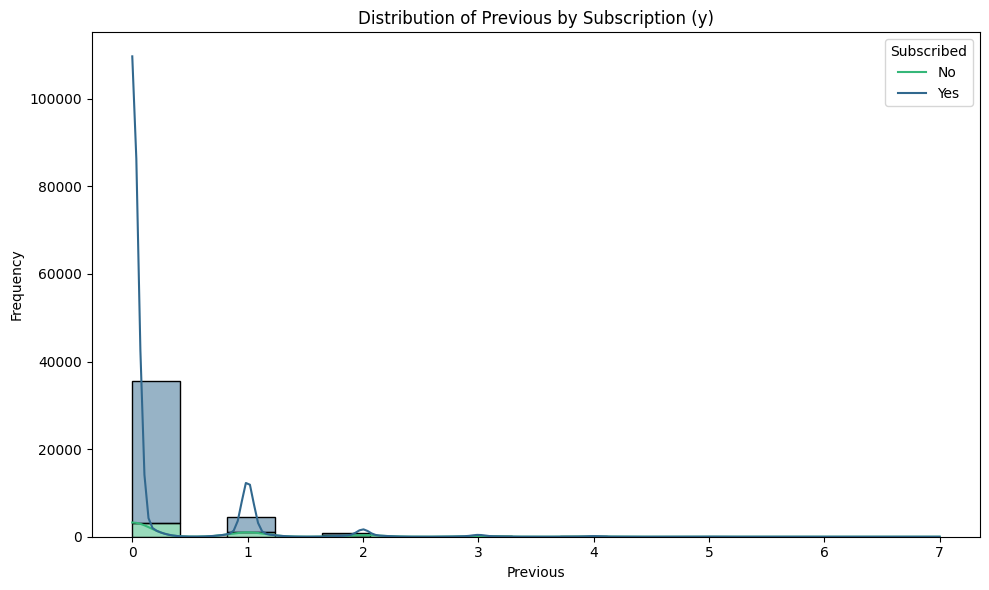

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


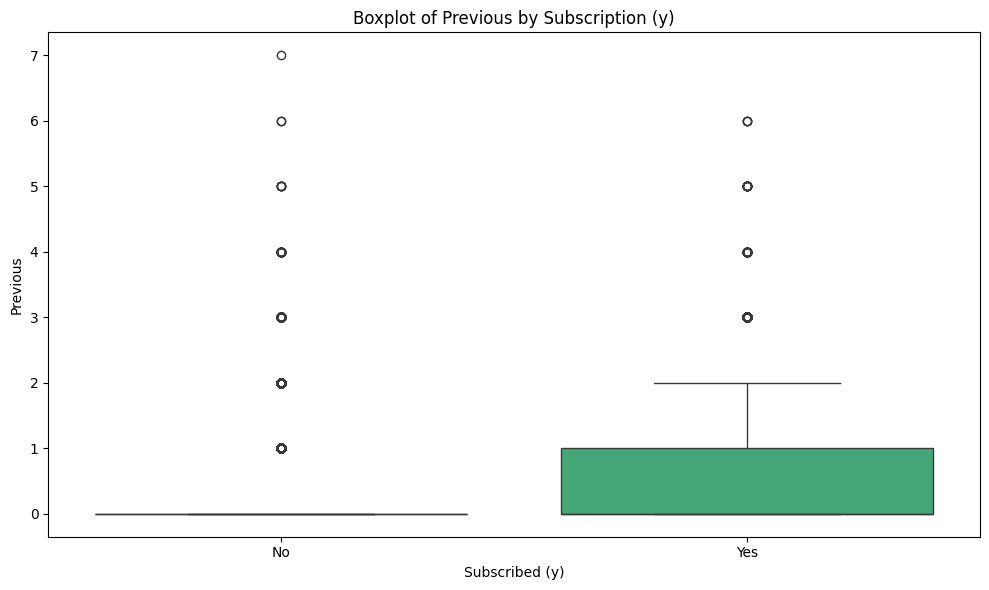


--- Analysis for Numerical Feature: Emp.Var.Rate ---
     count      mean       std  min  25%  50%  75%  max
y                                                      
0  36548.0  0.248875  1.482932 -3.4 -1.8  1.1  1.4  1.4
1   4640.0 -1.233448  1.623626 -3.4 -1.8 -1.8 -0.1  1.4


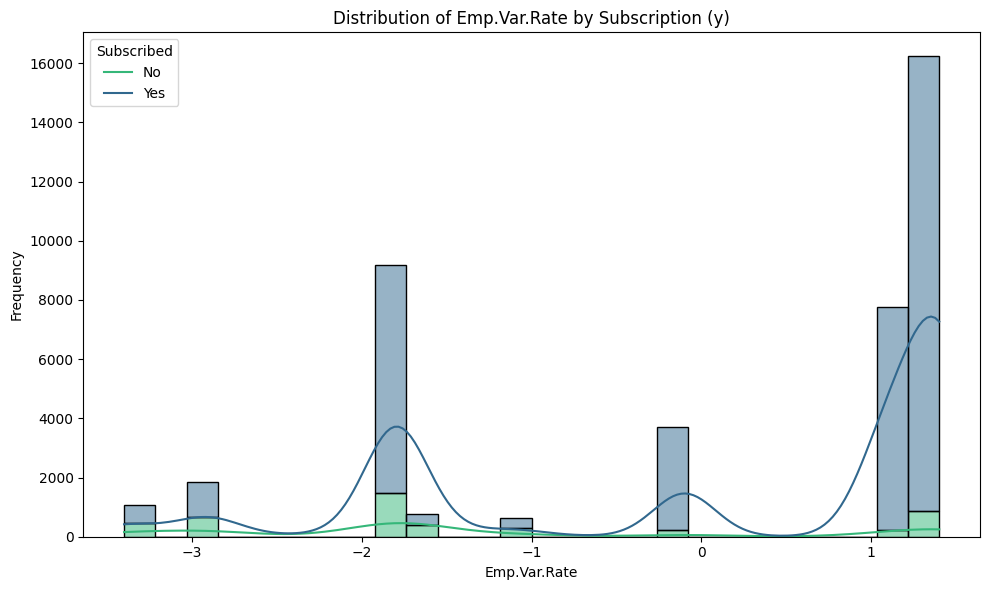

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


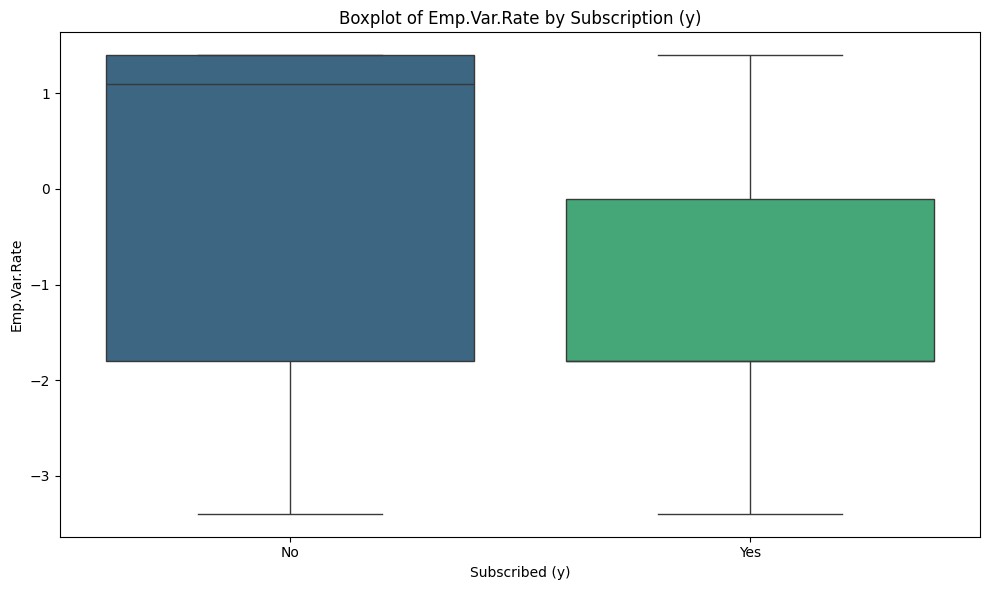


--- Analysis for Numerical Feature: Cons.Price.Idx ---
     count       mean       std     min     25%     50%     75%     max
y                                                                      
0  36548.0  93.603757  0.558993  92.201  93.075  93.918  93.994  94.767
1   4640.0  93.354386  0.676644  92.201  92.893  93.200  93.918  94.767


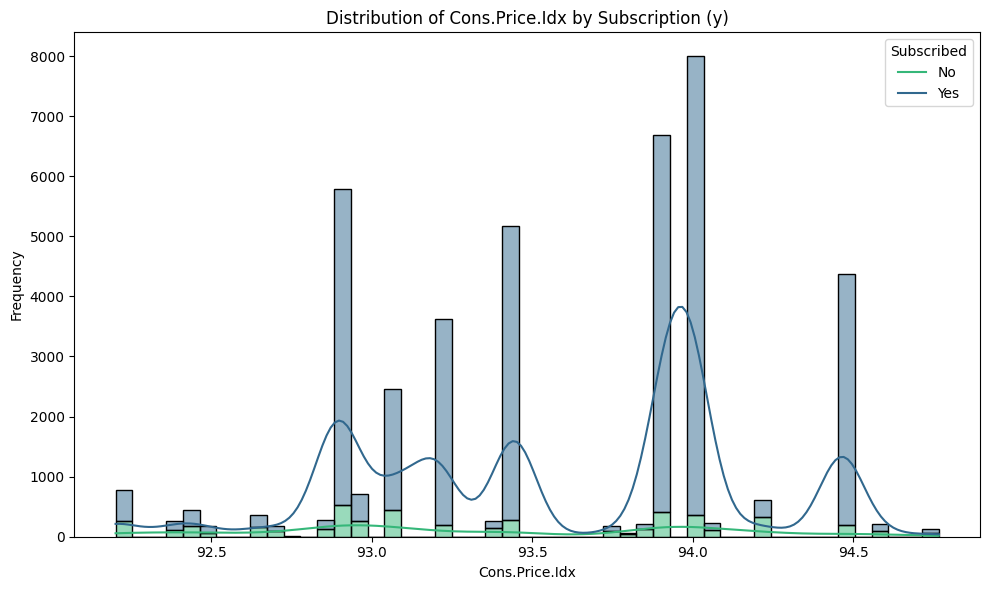

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


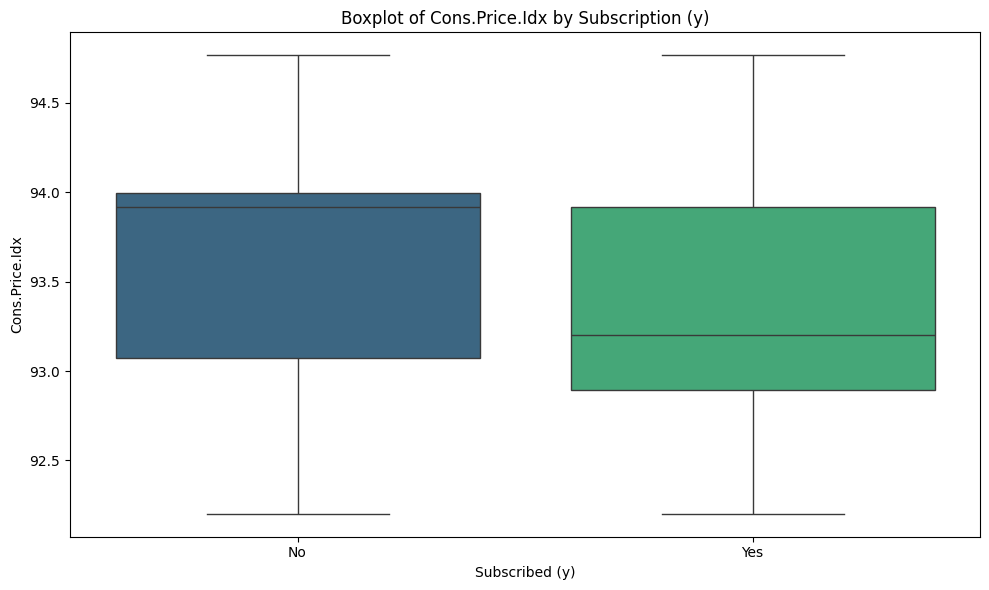


--- Analysis for Numerical Feature: Cons.Conf.Idx ---
     count       mean       std   min   25%   50%   75%   max
y                                                            
0  36548.0 -40.593097  4.391155 -50.8 -42.7 -41.8 -36.4 -26.9
1   4640.0 -39.789784  6.139668 -50.8 -46.2 -40.4 -36.1 -26.9


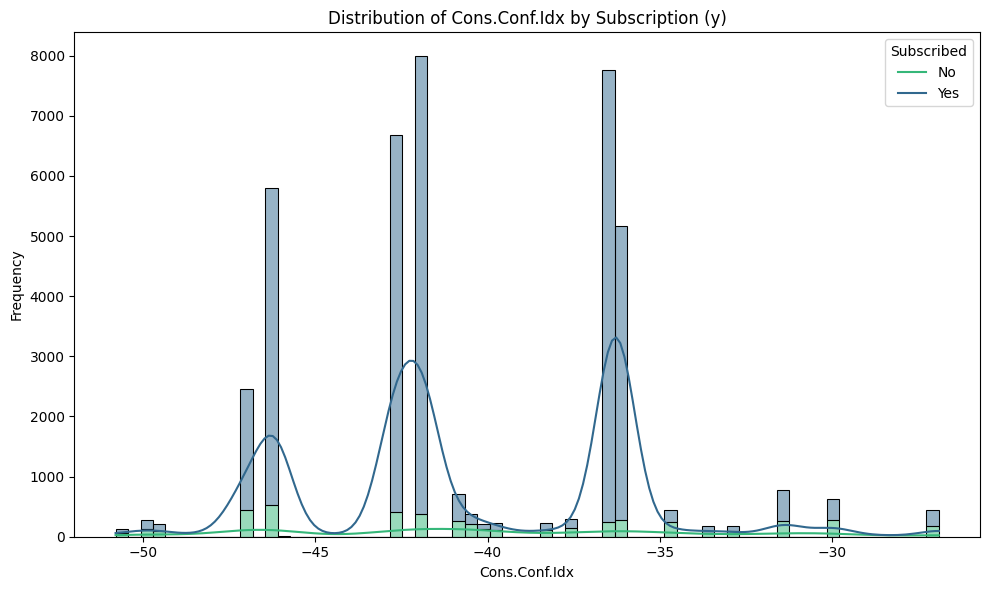

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


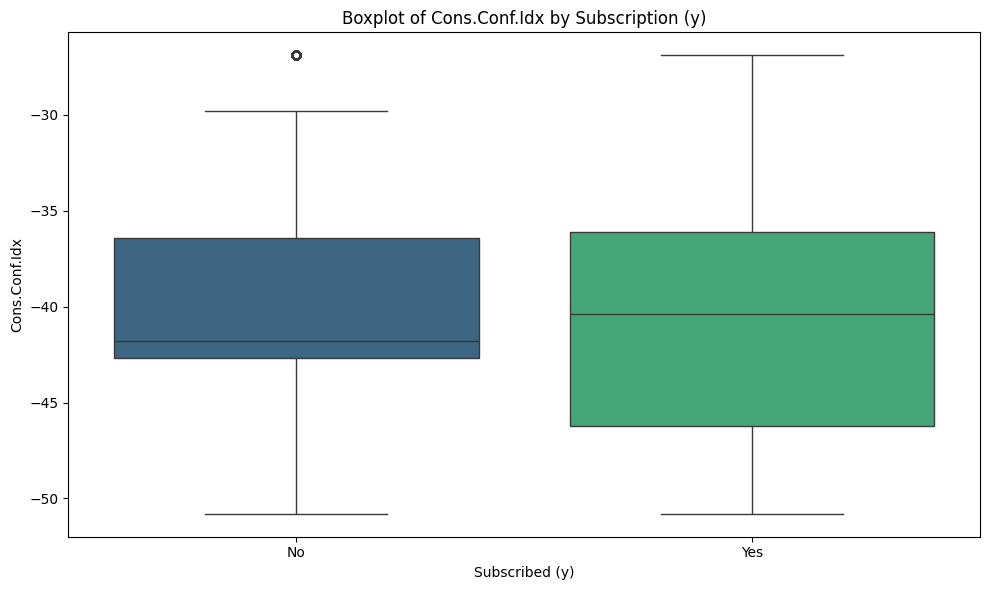


--- Analysis for Numerical Feature: Euribor3M ---
     count      mean       std    min    25%    50%    75%    max
y                                                                
0  36548.0  3.811491  1.638187  0.634  1.405  4.857  4.962  5.045
1   4640.0  2.123135  1.742598  0.634  0.849  1.266  4.406  5.045


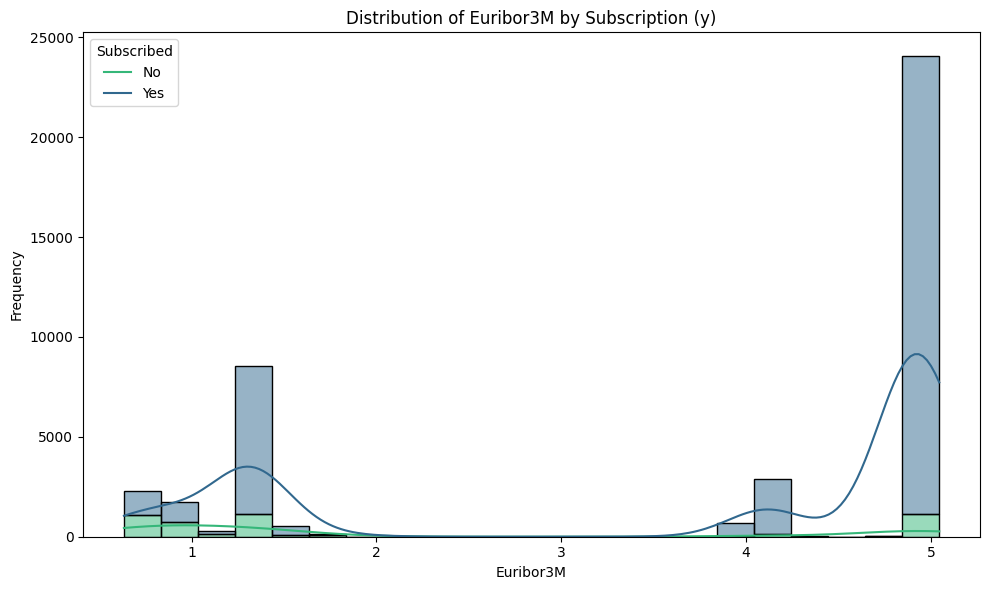

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


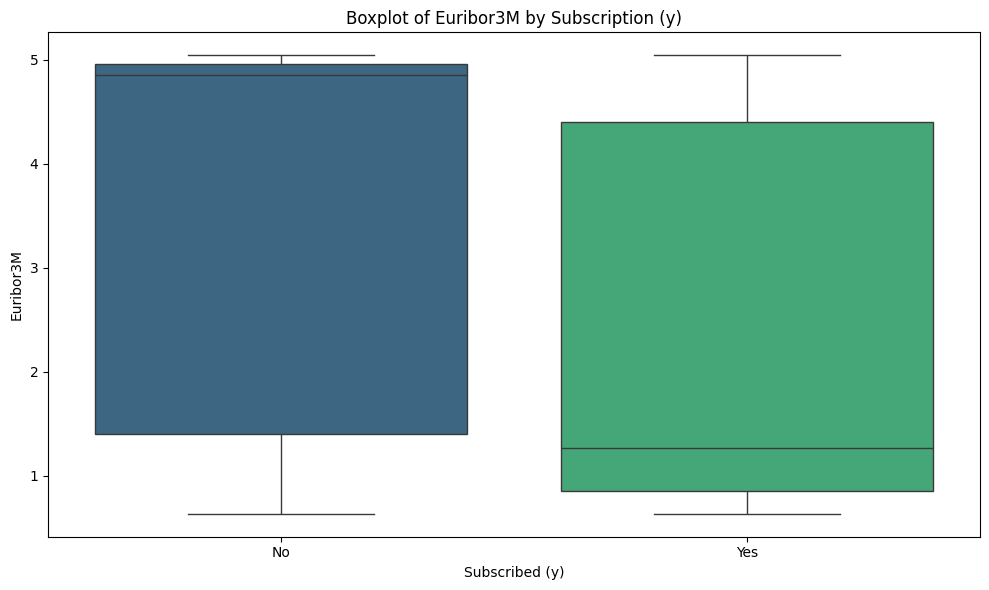


--- Analysis for Numerical Feature: Nr.Employed ---
     count         mean        std     min     25%     50%     75%     max
y                                                                         
0  36548.0  5176.166600  64.571979  4963.6  5099.1  5195.8  5228.1  5228.1
1   4640.0  5095.115991  87.572641  4963.6  5017.5  5099.1  5191.0  5228.1


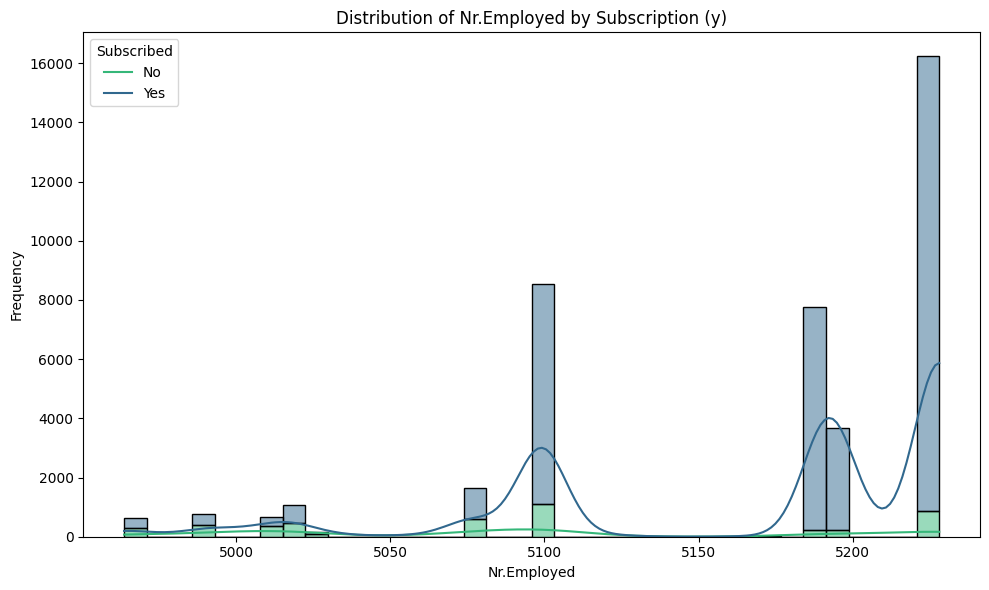

/tmp/ipython-input-989226425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y=col, palette='viridis')


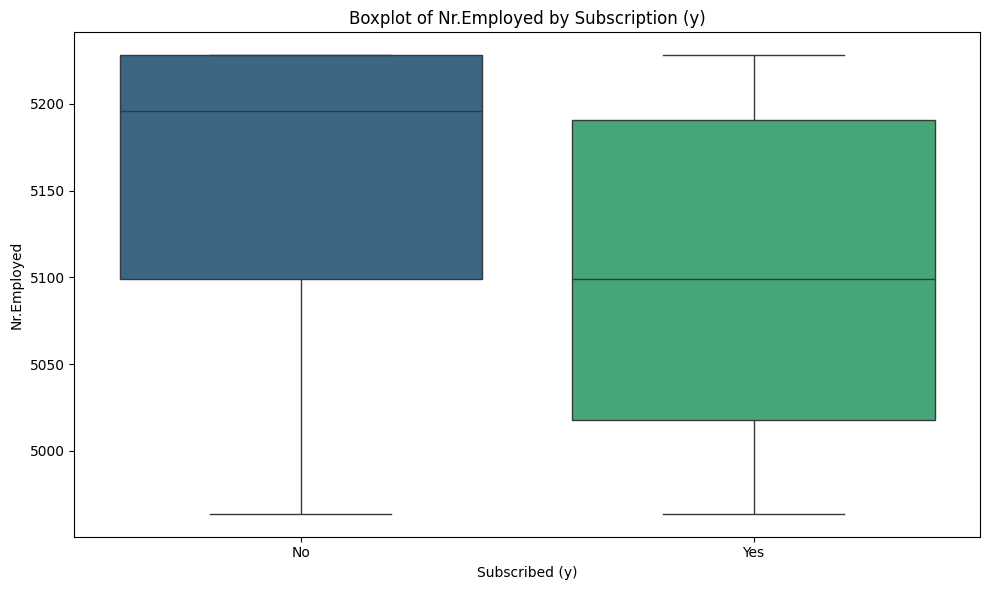

In [14]:
for col in numerical_cols:
    print(f"\n--- Analysis for Numerical Feature: {col.replace('_', ' ').title()} ---")

    # Descriptive statistics grouped by 'y'
    print(df.groupby('y')[col].describe())

    # Visualization: Histogram or Boxplot
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='y', kde=True, palette='viridis', multiple='stack')
    plt.title(f'Distribution of {col.replace('_', ' ').title()} by Subscription (y)')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Frequency')
    plt.legend(title='Subscribed', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

    # Another visualization: Boxplot for clear comparison of central tendency and spread
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='y', y=col, palette='viridis')
    plt.title(f'Boxplot of {col.replace('_', ' ').title()} by Subscription (y)')
    plt.xlabel('Subscribed (y)')
    plt.ylabel(col.replace('_', ' ').title())
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.tight_layout()
    plt.show()

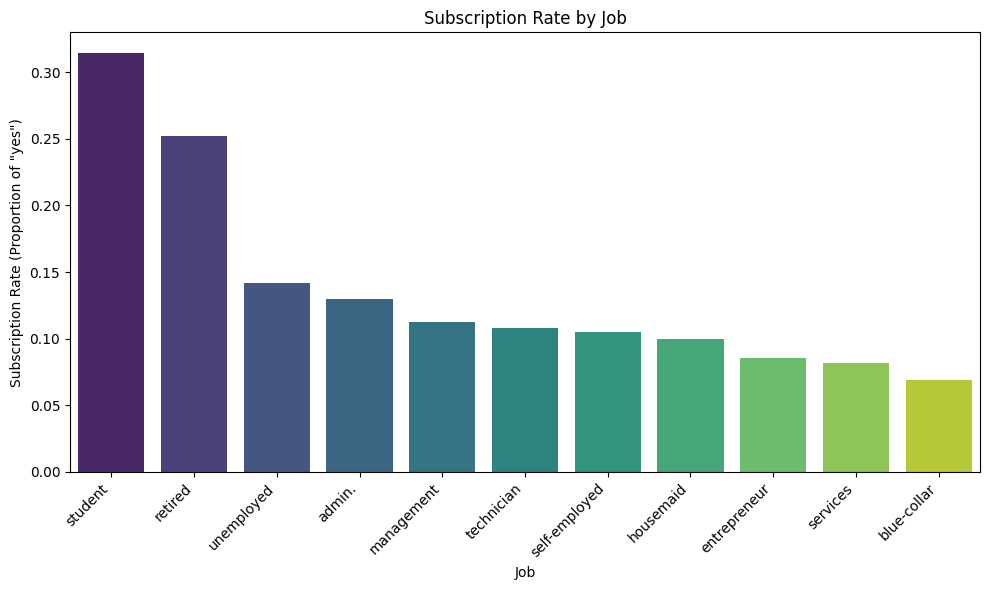

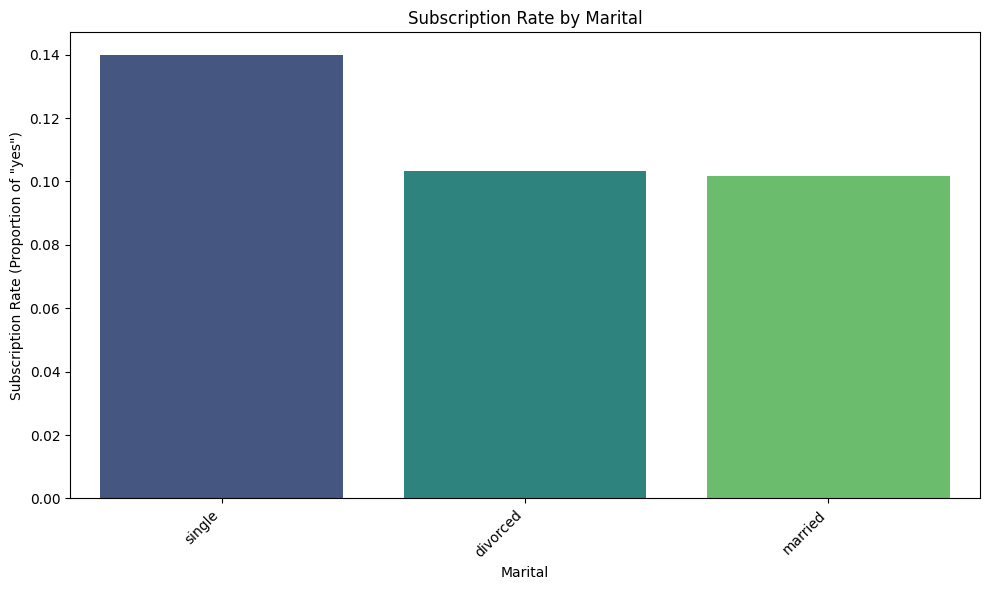

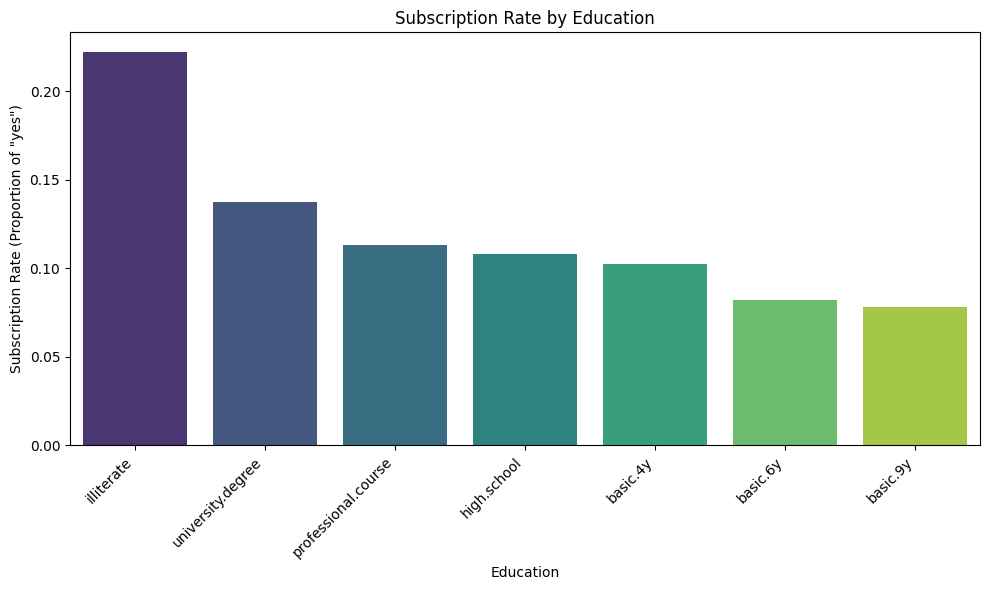

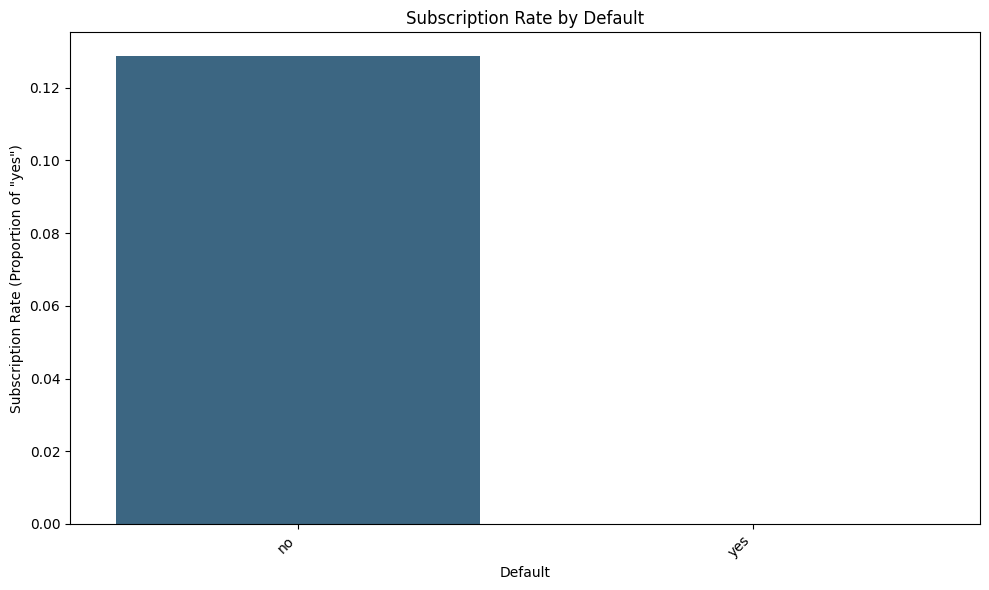

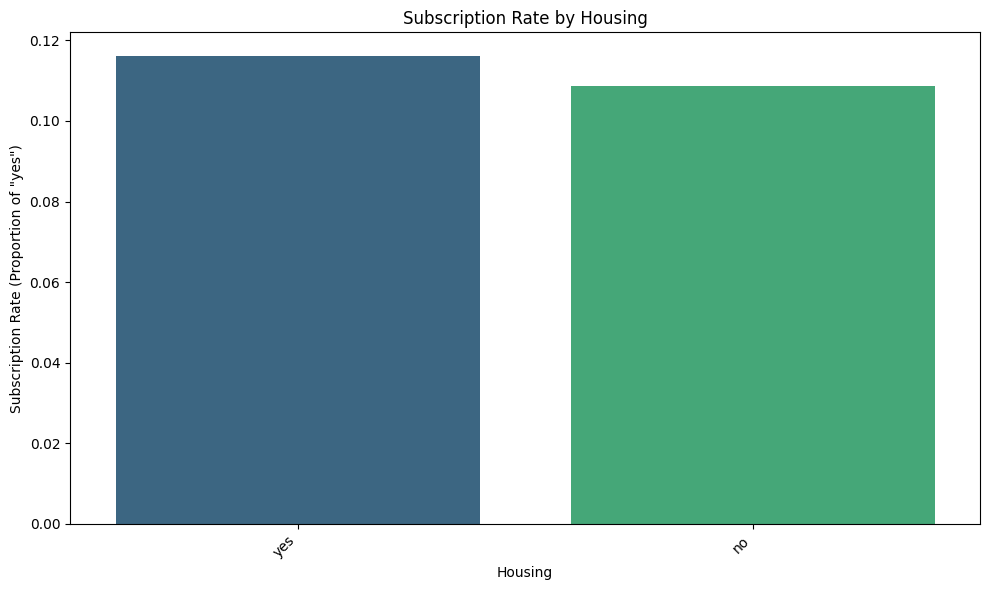

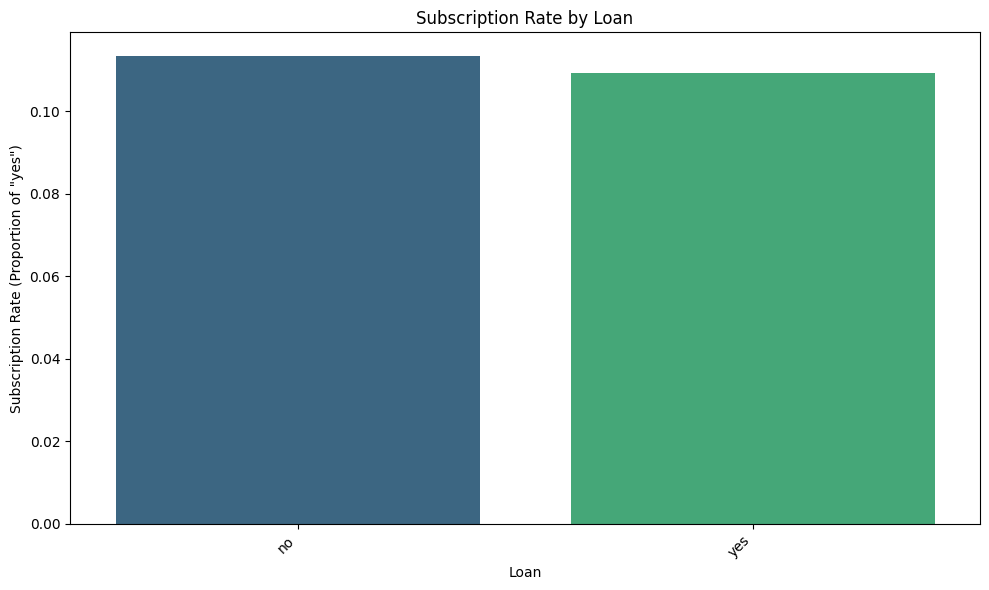

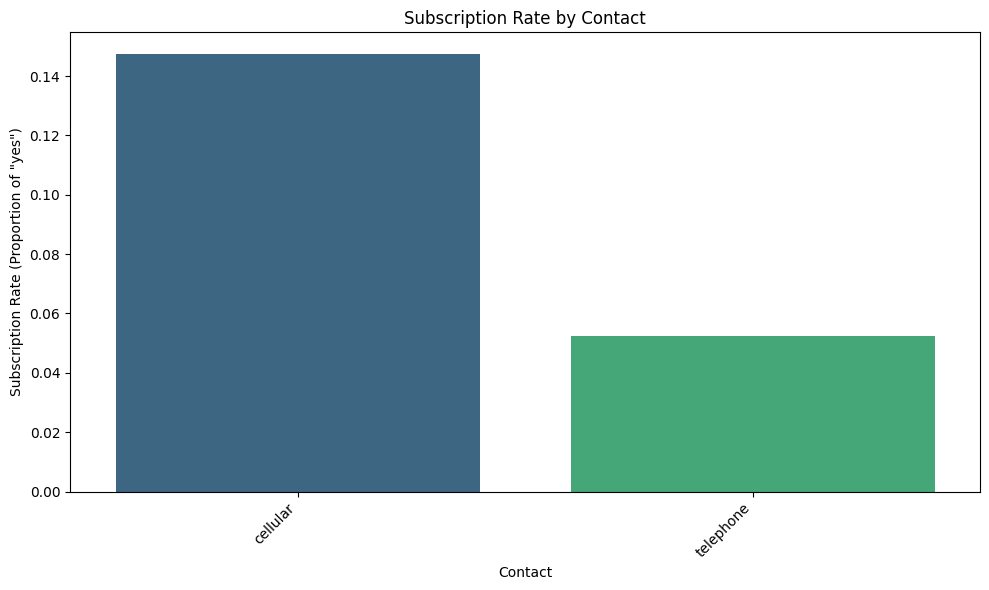

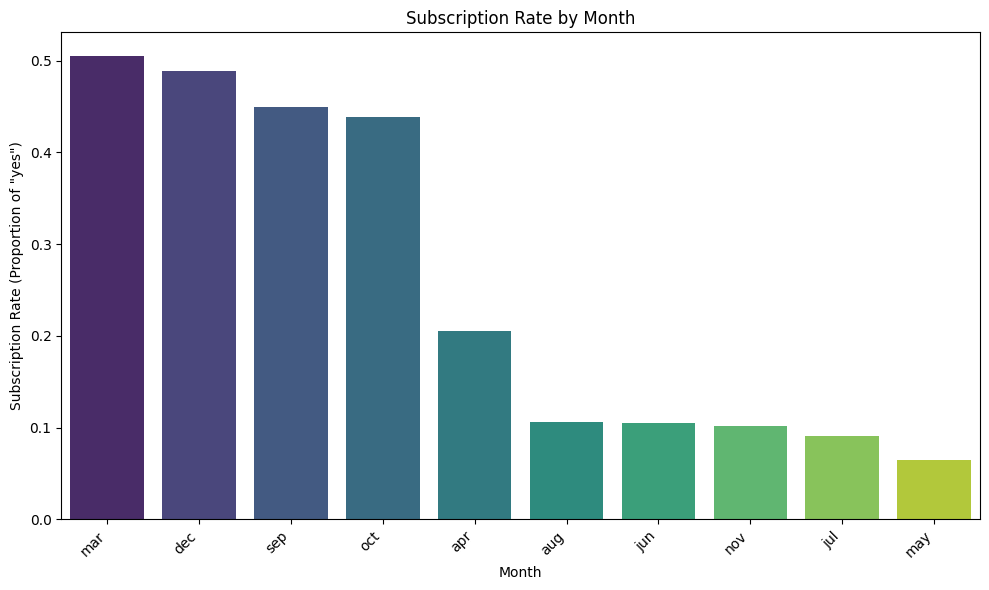

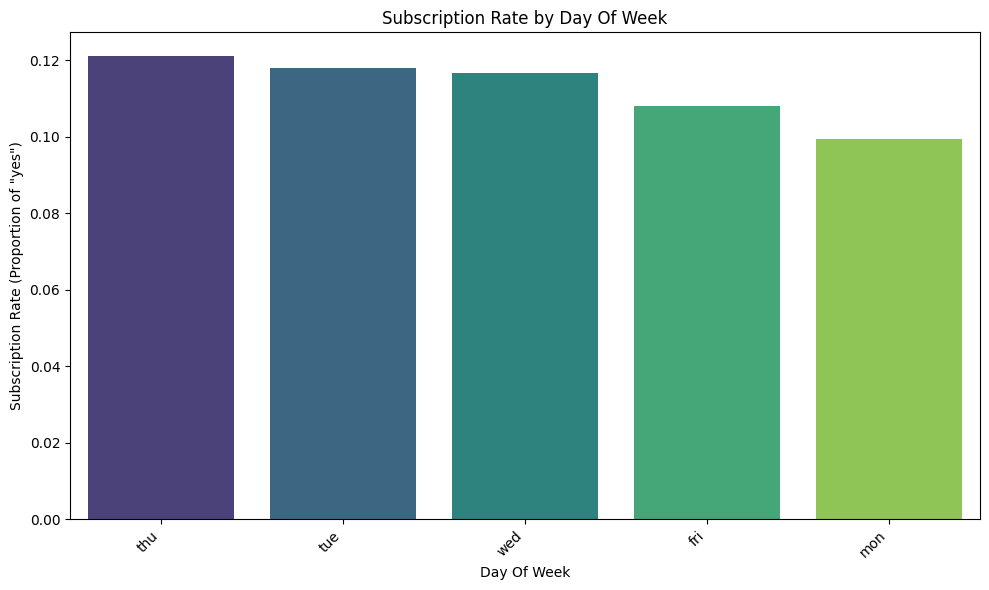

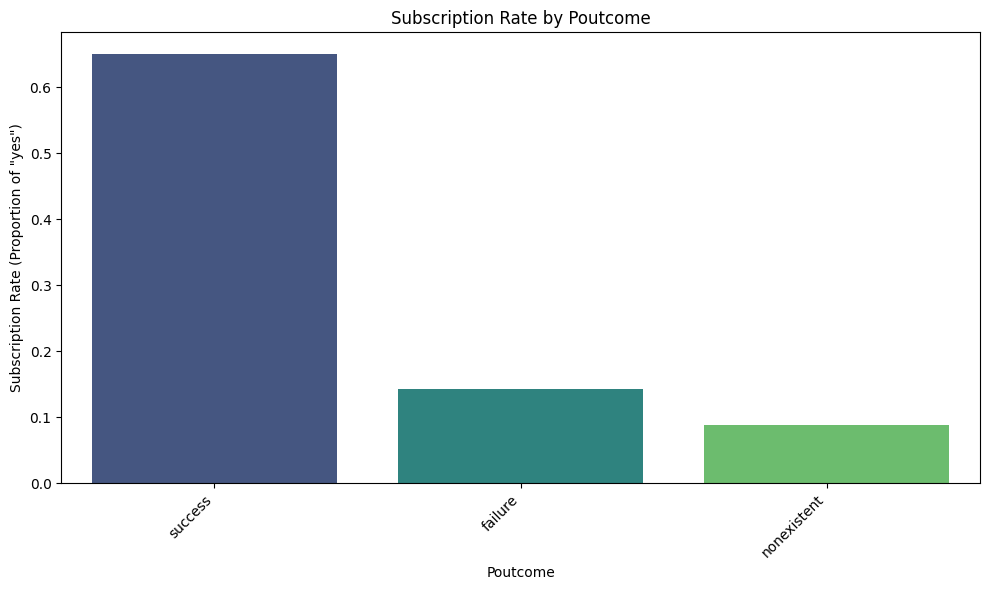

Finished plotting subscription rates for all categorical columns.


In [35]:
for col in categorical_cols:
    # Calculate the subscription rate for each category
    subscription_rates = df.groupby(col)['y'].mean().sort_values(ascending=False)

    # Create a bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=subscription_rates.index, y=subscription_rates.values, hue=subscription_rates.index, palette='viridis', legend=False)
    plt.title(f'Subscription Rate by {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Subscription Rate (Proportion of "yes")')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Finished plotting subscription rates for all categorical columns.")

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

Correlation Matrix:
                     age  duration  campaign     pdays  previous  \
age             1.000000 -0.000866  0.004594 -0.034369  0.024365   
duration       -0.000866  1.000000 -0.071699 -0.047577  0.020640   
campaign        0.004594 -0.071699  1.000000  0.052584 -0.079141   
pdays          -0.034369 -0.047577  0.052584  1.000000 -0.587514   
previous        0.024365  0.020640 -0.079141 -0.587514  1.000000   
emp.var.rate   -0.000371 -0.027968  0.150754  0.271004 -0.420489   
cons.price.idx  0.000857  0.005312  0.127836  0.078889 -0.203130   
cons.conf.idx   0.129372 -0.008173 -0.013733 -0.091342 -0.050936   
euribor3m       0.010767 -0.032897  0.135133  0.296899 -0.454494   
nr.employed    -0.017725 -0.044703  0.144095  0.372605 -0.501333   

                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
age                -0.000371        0.000857       0.129372   0.010767   
duration           -0.027968        0.005312      -0.008173  -0.032897   
campaign 

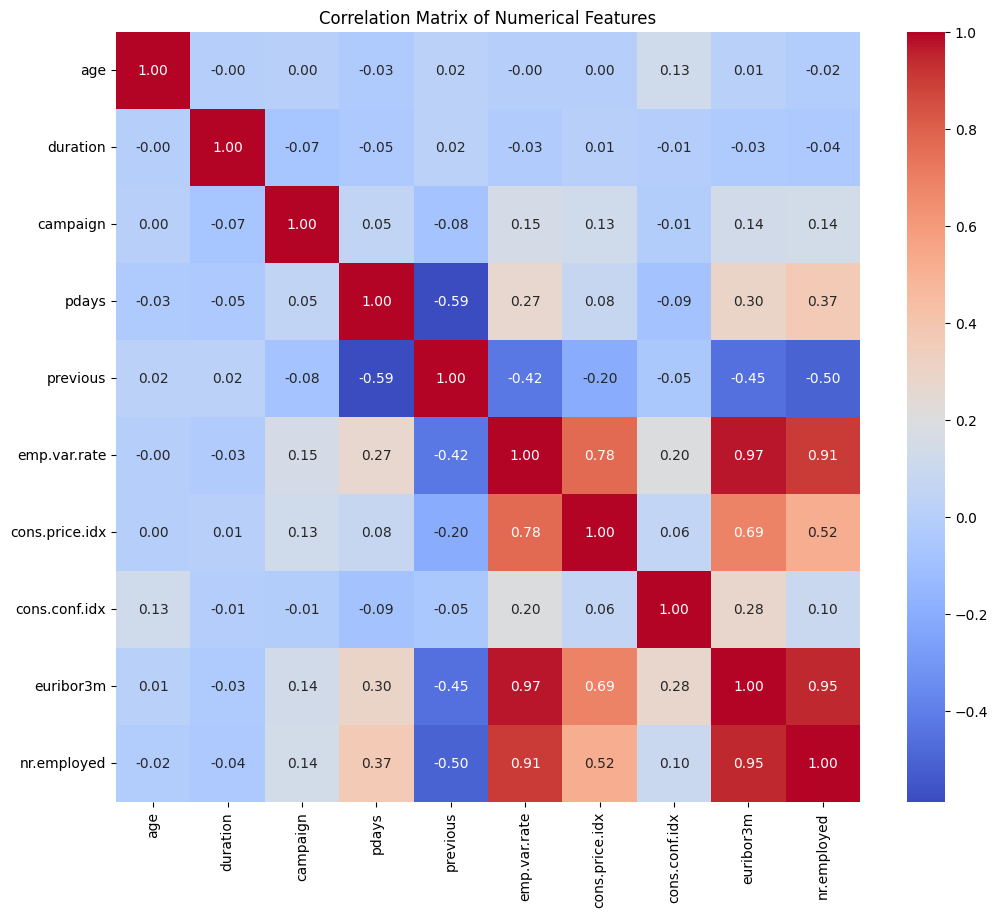

In [15]:
# Select only numerical columns for correlation calculation
# Ensure 'y' is included if it's numerical, otherwise it won't be in the correlation matrix
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

X = df.drop('y', axis=1)
y = df['y'].astype(int) # Ensure 'y' is explicitly integer type

print(f"Unique values in 'y' after robust conversion: {y.unique()}")

# Identify categorical columns (object type, excluding 'y' which is already handled)
categorical_cols_X = X.select_dtypes(include='object').columns

# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols_X, dummy_na=False) # dummy_na=False to not create a 'NaN' column for unknowns already replaced with np.nan

X = X.fillna(0) # Handle any NaNs that might remain in numerical columns after one-hot encoding

print(f"Shape of X after encoding and NaN handling: {X.shape}")
print(f"Shape of y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Unique values in 'y' after robust conversion: [0 1]
Shape of X after encoding and NaN handling: (41188, 57)
Shape of y: (41188,)
X_train shape: (32950, 57)
X_test shape: (8238, 57)
y_train shape: (32950,)
y_test shape: (8238,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize DummyClassifier with 'most_frequent' strategy as a baseline
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)

# Fit the model to the training data
dummy_clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dummy = dummy_clf.predict(X_test)

# Evaluate the baseline model
accuracy = accuracy_score(y_test, y_pred_dummy)
precision = precision_score(y_test, y_pred_dummy, zero_division=0)
recall = recall_score(y_test, y_pred_dummy, zero_division=0)
f1 = f1_score(y_test, y_pred_dummy, zero_division=0)

print(f"Baseline Model (DummyClassifier - Most Frequent) Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Baseline Model (DummyClassifier - Most Frequent) Performance:
Accuracy: 0.8874
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [18]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for older sklearn versions

# Fit the model to the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


### Problem 9: Score the Model

What is the accuracy of your model?

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate accuracy
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg, zero_division=0)
recall = recall_score(y_test, y_pred_log_reg, zero_division=0)
f1 = f1_score(y_test, y_pred_log_reg, zero_division=0)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {log_reg_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Logistic Regression Model Performance:
Accuracy: 0.9133
Precision: 0.6989
Recall: 0.4052
F1-Score: 0.5130


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [20]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# Prepare a list to store model results
model_results = []

# --- Logistic Regression (already trained) ---
y_pred_log_reg_train = log_reg_model.predict(X_train)
y_pred_log_reg_test = log_reg_model.predict(X_test)
log_reg_train_accuracy = accuracy_score(y_train, y_pred_log_reg_train)
log_reg_test_accuracy = accuracy_score(y_test, y_pred_log_reg_test)

# For training time, we need to re-measure it as it wasn't captured explicitly before.
start_time = time.time()
log_reg_model_for_time = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model_for_time.fit(X_train, y_train)
log_reg_train_time = time.time() - start_time

model_results.append({
    'Model': 'Logistic Regression',
    'Train Time': log_reg_train_time,
    'Train Accuracy': log_reg_train_accuracy,
    'Test Accuracy': log_reg_test_accuracy
})

# --- K-Nearest Neighbors ---
knn_model = KNeighborsClassifier()
start_time = time.time()
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start_time

y_pred_knn_train = knn_model.predict(X_train)
y_pred_knn_test = knn_model.predict(X_test)
knn_train_accuracy = accuracy_score(y_train, y_pred_knn_train)
knn_test_accuracy = accuracy_score(y_test, y_pred_knn_test)

model_results.append({
    'Model': 'K-Nearest Neighbors',
    'Train Time': knn_train_time,
    'Train Accuracy': knn_train_accuracy,
    'Test Accuracy': knn_test_accuracy
})

# --- Decision Tree ---
dt_model = DecisionTreeClassifier(random_state=42)
start_time = time.time()
dt_model.fit(X_train, y_train)
dt_train_time = time.time() - start_time

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)
dt_train_accuracy = accuracy_score(y_train, y_pred_dt_train)
dt_test_accuracy = accuracy_score(y_test, y_pred_dt_test)

model_results.append({
    'Model': 'Decision Tree',
    'Train Time': dt_train_time,
    'Train Accuracy': dt_train_accuracy,
    'Test Accuracy': dt_test_accuracy
})

# --- Support Vector Machine (SVC) ---
# SVC can be very slow on large datasets, so consider a smaller subset or a different kernel for practical use.
# For default comparison, we will run it, but be aware it might take a long time.
svc_model = SVC(random_state=42)
print("\nFitting Support Vector Machine (SVC)... This may take a while.")
start_time = time.time()
svc_model.fit(X_train, y_train)
svc_train_time = time.time() - start_time

y_pred_svc_train = svc_model.predict(X_train)
y_pred_svc_test = svc_model.predict(X_test)
svc_train_accuracy = accuracy_score(y_train, y_pred_svc_train)
svc_test_accuracy = accuracy_score(y_test, y_pred_svc_test)

model_results.append({
    'Model': 'Support Vector Machine',
    'Train Time': svc_train_time,
    'Train Accuracy': svc_train_accuracy,
    'Test Accuracy': svc_test_accuracy
})

# Create a DataFrame to display the results
comparison_df = pd.DataFrame(model_results)
print("\nModel Comparison Results:")
print(comparison_df.round(4))



Fitting Support Vector Machine (SVC)... This may take a while.

Model Comparison Results:
                    Model  Train Time  Train Accuracy  Test Accuracy
0     Logistic Regression      0.3485          0.9096         0.9133
1     K-Nearest Neighbors      0.0380          0.9309         0.9079
2           Decision Tree      0.2926          1.0000         0.8912
3  Support Vector Machine     23.6242          0.8976         0.8980


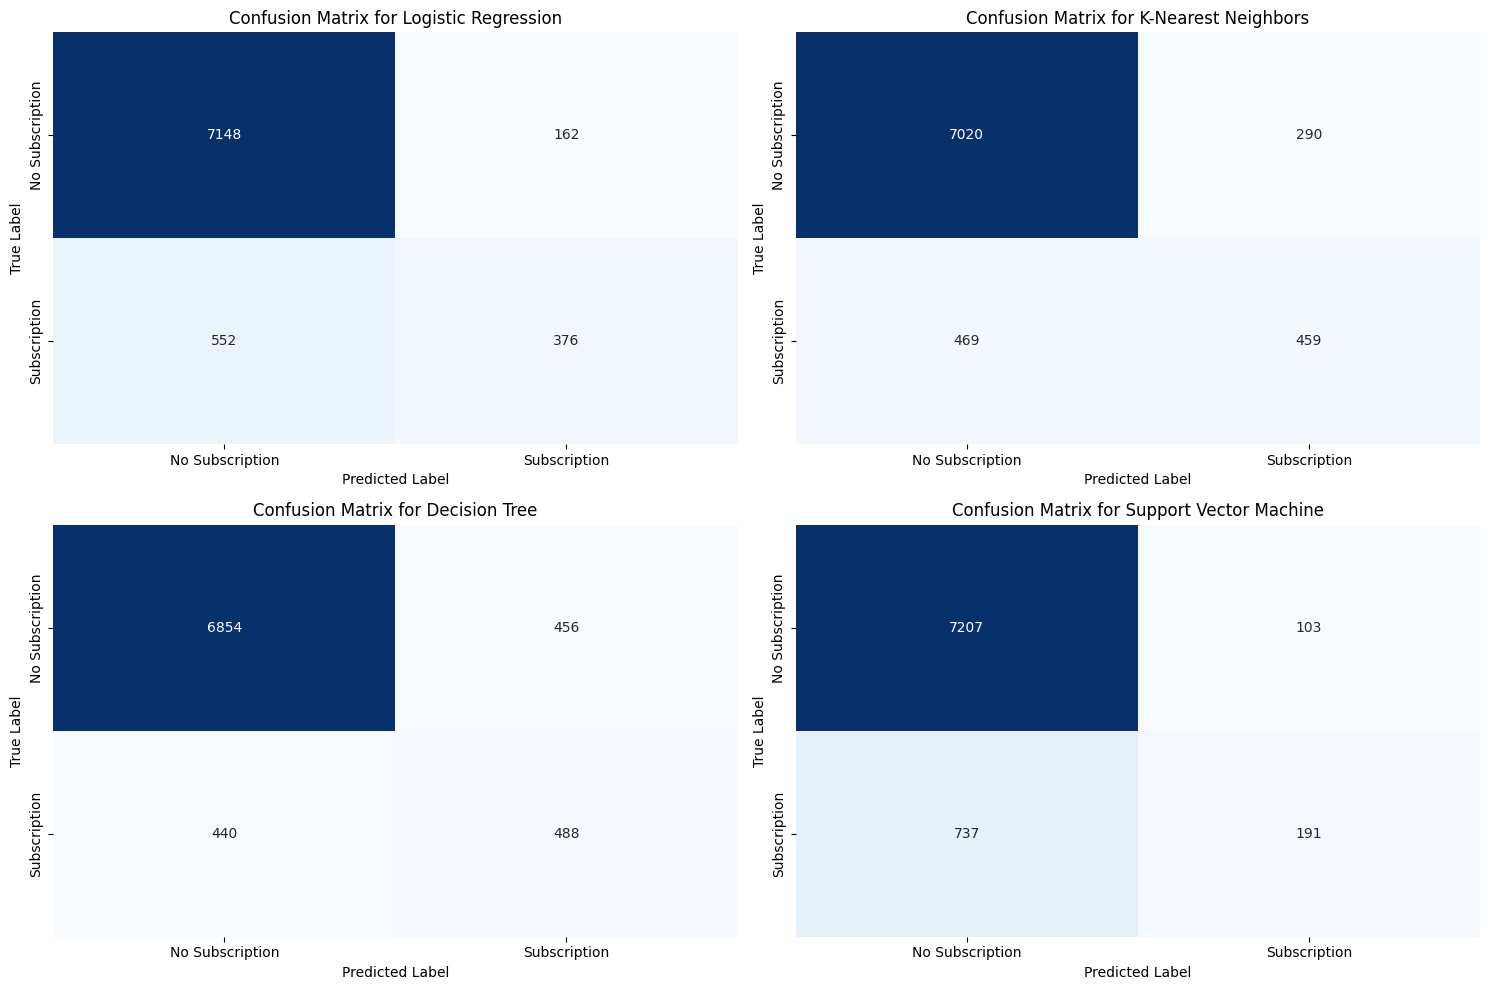

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Logistic Regression': log_reg_model,
    'K-Nearest Neighbors': knn_model,
    'Decision Tree': dt_model,
    'Support Vector Machine': svc_model
}

plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Subscription', 'Subscription'],
                yticklabels=['No Subscription', 'Subscription'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [36]:
from sklearn.model_selection import GridSearchCV
import time

# Initialize an empty list to store model results after tuning
tuned_model_results = []

print("GridSearchCV and time module imported. tuned_model_results list initialized.")

GridSearchCV and time module imported. tuned_model_results list initialized.


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Logistic Regression ---
print("\n--- Tuning Logistic Regression ---")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

log_reg_model_tuned = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for saga solver
grid_search_lr = GridSearchCV(log_reg_model_tuned, param_grid_lr, scoring='f1', cv=5, n_jobs=-1, verbose=1)

start_time = time.time()
grid_search_lr.fit(X_train, y_train)
lr_train_time = time.time() - start_time

best_lr_model = grid_search_lr.best_estimator_
best_lr_params = grid_search_lr.best_params_

y_pred_lr_train = best_lr_model.predict(X_train)
y_pred_lr_test = best_lr_model.predict(X_test)

lr_train_accuracy = accuracy_score(y_train, y_pred_lr_train)
lr_test_accuracy = accuracy_score(y_test, y_pred_lr_test)
lr_precision = precision_score(y_test, y_pred_lr_test, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr_test, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr_test, zero_division=0)

tuned_model_results.append({
    'Model': 'Logistic Regression Tuned',
    'Train Time': lr_train_time,
    'Train Accuracy': lr_train_accuracy,
    'Test Accuracy': lr_test_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'Best Params': best_lr_params
})

print(f"Logistic Regression Tuned Best Params: {best_lr_params}")
print(f"Logistic Regression Tuned Test F1-Score: {lr_f1:.4f}")


--- Tuning Logistic Regression ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Logistic Regression Tuned Best Params: {'C': 1, 'solver': 'liblinear'}
Logistic Regression Tuned Test F1-Score: 0.5130


In [31]:
from sklearn.neighbors import KNeighborsClassifier

# --- K-Nearest Neighbors ---
print("--- Tuning K-Nearest Neighbors ---")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_model_tuned = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn_model_tuned, param_grid_knn, scoring='f1', cv=5, n_jobs=-1, verbose=1)

start_time = time.time()
grid_search_knn.fit(X_train, y_train)
knn_train_time = time.time() - start_time

best_knn_model = grid_search_knn.best_estimator_
best_knn_params = grid_search_knn.best_params_

y_pred_knn_train = best_knn_model.predict(X_train)
y_pred_knn_test = best_knn_model.predict(X_test)

knn_train_accuracy = accuracy_score(y_train, y_pred_knn_train)
knn_test_accuracy = accuracy_score(y_test, y_pred_knn_test)
knn_precision = precision_score(y_test, y_pred_knn_test, zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn_test, zero_division=0)
k_knn_f1 = f1_score(y_test, y_pred_knn_test, zero_division=0)

tuned_model_results.append({
    'Model': 'K-Nearest Neighbors Tuned',
    'Train Time': knn_train_time,
    'Train Accuracy': knn_train_accuracy,
    'Test Accuracy': knn_test_accuracy,
    'Precision': knn_precision,
    'Recall': knn_recall,
    'F1-Score': k_knn_f1,
    'Best Params': best_knn_params
})

print(f"K-Nearest Neighbors Tuned Best Params: {best_knn_params}")
print(f"K-Nearest Neighbors Tuned Test F1-Score: {k_knn_f1:.4f}")

--- Tuning K-Nearest Neighbors ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
K-Nearest Neighbors Tuned Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
K-Nearest Neighbors Tuned Test F1-Score: 0.5551


In [32]:
from sklearn.tree import DecisionTreeClassifier

# --- Decision Tree ---
print("\n--- Tuning Decision Tree ---")
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model_tuned = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(dt_model_tuned, param_grid_dt, scoring='f1', cv=5, n_jobs=-1, verbose=1)

start_time = time.time()
grid_search_dt.fit(X_train, y_train)
dt_train_time = time.time() - start_time

best_dt_model = grid_search_dt.best_estimator_
best_dt_params = grid_search_dt.best_params_

y_pred_dt_train = best_dt_model.predict(X_train)
y_pred_dt_test = best_dt_model.predict(X_test)

dt_train_accuracy = accuracy_score(y_train, y_pred_dt_train)
dt_test_accuracy = accuracy_score(y_test, y_pred_dt_test)
dt_precision = precision_score(y_test, y_pred_dt_test, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt_test, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt_test, zero_division=0)

tuned_model_results.append({
    'Model': 'Decision Tree Tuned',
    'Train Time': dt_train_time,
    'Train Accuracy': dt_train_accuracy,
    'Test Accuracy': dt_test_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1,
    'Best Params': best_dt_params
})

print(f"Decision Tree Tuned Best Params: {best_dt_params}")
print(f"Decision Tree Tuned Test F1-Score: {dt_f1:.4f}")


--- Tuning Decision Tree ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Decision Tree Tuned Best Params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree Tuned Test F1-Score: 0.5927


In [33]:
from sklearn.svm import SVC

# --- Support Vector Machine (SVC) ---
print("\n--- Tuning Support Vector Machine ---")
# Reduced search space for SVC due to high computational cost
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svc_model_tuned = SVC(random_state=42)
# Using cv=3 to reduce computation time, as SVC with GridSearchCV can be very slow
grid_search_svc = GridSearchCV(svc_model_tuned, param_grid_svc, scoring='f1', cv=3, n_jobs=-1, verbose=1)

print("Fitting Support Vector Machine (SVC) GridSearchCV... This may take a substantial amount of time.")
start_time = time.time()
grid_search_svc.fit(X_train, y_train)
svc_train_time = time.time() - start_time

best_svc_model = grid_search_svc.best_estimator_
best_svc_params = grid_search_svc.best_params_

y_pred_svc_train = best_svc_model.predict(X_train)
y_pred_svc_test = best_svc_model.predict(X_test)

svc_train_accuracy = accuracy_score(y_train, y_pred_svc_train)
svc_test_accuracy = accuracy_score(y_test, y_pred_svc_test)
svc_precision = precision_score(y_test, y_pred_svc_test, zero_division=0)
svc_recall = recall_score(y_test, y_pred_svc_test, zero_division=0)
svc_f1 = f1_score(y_test, y_pred_svc_test, zero_division=0)

tuned_model_results.append({
    'Model': 'Support Vector Machine Tuned',
    'Train Time': svc_train_time,
    'Train Accuracy': svc_train_accuracy,
    'Test Accuracy': svc_test_accuracy,
    'Precision': svc_precision,
    'Recall': svc_recall,
    'F1-Score': svc_f1,
    'Best Params': best_svc_params
})

print(f"Support Vector Machine Tuned Best Params: {best_svc_params}")
print(f"Support Vector Machine Tuned Test F1-Score: {svc_f1:.4f}")


--- Tuning Support Vector Machine ---
Fitting Support Vector Machine (SVC) GridSearchCV... This may take a substantial amount of time.
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Support Vector Machine Tuned Best Params: {'C': 10, 'kernel': 'linear'}
Support Vector Machine Tuned Test F1-Score: 0.4591


In [34]:
import pandas as pd

# Create a DataFrame to display the results of tuned models
comparison_df_tuned = pd.DataFrame(tuned_model_results)
print("\n--- Tuned Model Comparison Results ---")
print(comparison_df_tuned.round(4))



--- Tuned Model Comparison Results ---
                          Model  Train Time  Train Accuracy  Test Accuracy  \
0     Logistic Regression Tuned    881.9653          0.9096         0.9133   
1     K-Nearest Neighbors Tuned    541.0063          0.9241         0.9103   
2           Decision Tree Tuned     42.8643          0.9160         0.9184   
3  Support Vector Machine Tuned    773.2268          0.8707         0.8699   

   Precision  Recall  F1-Score  \
0     0.6989  0.4052    0.5130   
1     0.6289  0.4968    0.5551   
2     0.6773  0.5269    0.5927   
3     0.4317  0.4903    0.4591   

                                         Best Params  
0                    {'C': 1, 'solver': 'liblinear'}  
1  {'metric': 'manhattan', 'n_neighbors': 9, 'wei...  
2  {'max_depth': 5, 'min_samples_leaf': 4, 'min_s...  
3                      {'C': 10, 'kernel': 'linear'}  


## Tuned Model Summary Report

### Overview
This report summarizes the performance of various classification models after hyperparameter tuning, with a focus on identifying the best model for predicting client subscription to a term deposit. The models evaluated include Logistic Regression, K-Nearest Neighbors, Decision Tree, and Support Vector Machine, all tuned to optimize the F1-score.

### Tuned Model Comparison Results

| Model                        | Train Time | Train Accuracy | Test Accuracy | Precision | Recall | F1-Score | Best Params                                            |
|------------------------------|------------|----------------|---------------|-----------|--------|----------|--------------------------------------------------------|
| Logistic Regression Tuned    | 881.9653   | 0.9096         | 0.9133        | 0.6989    | 0.4052 | 0.5130   | {'C': 1, 'solver': 'liblinear'}                        |
| K-Nearest Neighbors Tuned    | 541.0063   | 0.9241         | 0.9103        | 0.6289    | 0.4968 | 0.5551   | {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'} |
| Decision Tree Tuned          | 42.8643    | 0.9160         | 0.9184        | 0.6773    | 0.5269 | 0.5927   | {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2} |
| Support Vector Machine Tuned | 773.2268   | 0.8707         | 0.8699        | 0.4317    | 0.4903 | 0.4591   | {'C': 10, 'kernel': 'linear'}                          |

### Best Model for Prediction
Based on the F1-score, the **Decision Tree Tuned** model demonstrates the best performance among all tuned classifiers, achieving an F1-score of **0.5927**. This indicates a good balance between precision and recall, which is crucial for an imbalanced dataset where predicting the minority class ('yes' subscription) is important.

Key characteristics of the best Decision Tree model:
- **Train Time:** Approximately 42.86 seconds (significantly faster than Logistic Regression, KNN, and SVM)
- **Test Accuracy:** 0.9184
- **Precision:** 0.6773
- **Recall:** 0.5269
- **Best Parameters:** `{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}`

### Conclusion
The **Decision Tree Tuned** model is recommended as the best model for predicting client subscription to a term deposit, given its superior F1-score and comparatively efficient training time. While other models showed reasonable performance, the Decision Tree offered the best trade-off between predictive power and computational cost in this tuning exercise.